In [30]:
path = "./data/housing.csv"

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#Cargamos train_test_split
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
df = pd.read_csv(path)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [44]:
#pipeline
from sklearn.pipeline import Pipeline
X = df[['median_house_value','median_house_value']]
y = df['median_house_value']

In [45]:
#Dividir datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1,random_state=42)
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
])

In [46]:
df[['median_house_value','ocean_proximity']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_house_value  20640 non-null  float64
 1   ocean_proximity     20640 non-null  object 
dtypes: float64(1), object(1)
memory usage: 322.6+ KB


In [49]:
#Validacion cruzada (cross validation k = 5)
cv_result = cross_validate(estimator=pipeline, X=X_train, y=y_train,cv=3, scoring = {
    'R2' : 'r2',
    'MAE' : 'neg_mean_absolute_error',
    'RMSE' : 'neg_root_mean_squared_error'
},
return_train_score = True
)
resultados_cv = pd.DataFrame({
    'Fold': np.arange(1,4),
    'R2': cv_result['test_R2'],
    'MAE': -cv_result['test_MAE'],
    'RMSE': -cv_result['test_RMSE']
})
print(f"Resultados por Fold: {resultados_cv}")
#Promedios de la validacion cruzada
r2_prom = cv_result['test_R2'].mean()
mae_prom = cv_result['test_MAE'].mean()
rmse_prom = cv_result['test_RMSE'].mean()


#Entrenamiento
pipeline.fit(X_train, y_train)
#prediccion
y_pred = pipeline.predict(X_test)
#Evaluacion del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE {mae}, RMSE {rmse} y r2 {r2}')

Resultados por Fold:    Fold   R2           MAE          RMSE
0     1  1.0  1.472394e-10  1.910824e-10
1     2  1.0  7.101579e-11  9.049656e-11
2     3  1.0  3.800137e-11  5.731303e-11
MAE 1.7069593972577026e-10, RMSE 2.1493069346964933e-10 y r2 1.0


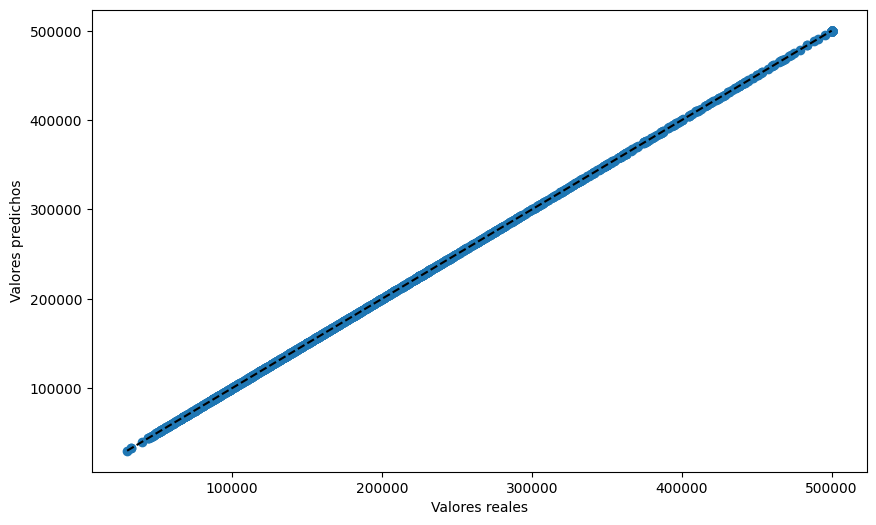

In [50]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.show()


Text(0, 0.5, 'Residuos')

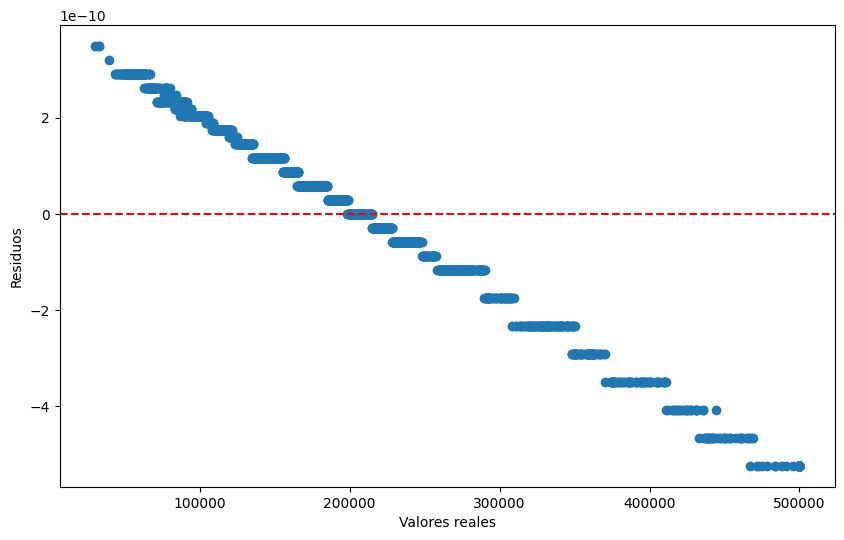

In [51]:
#residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_test, residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Residuos')

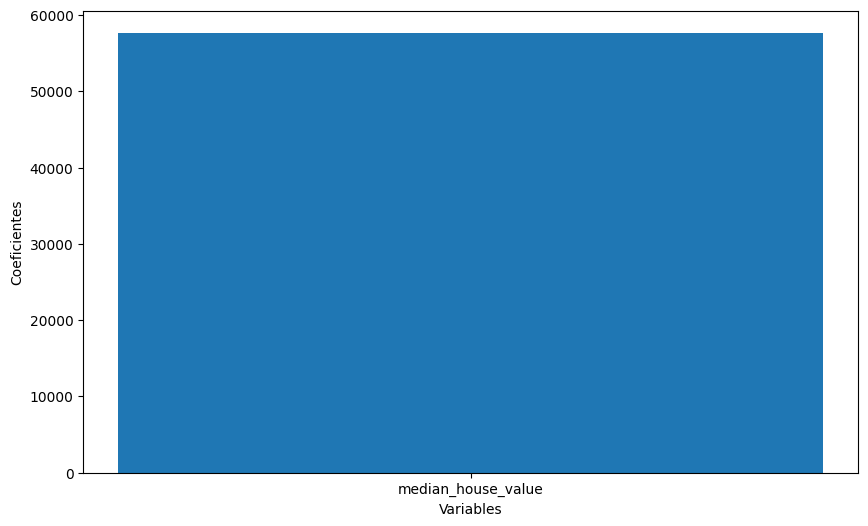

In [52]:
#Importancia estadistica (p-values)
coeficientes = pd.DataFrame({
    "Variable":X.columns,
    "Coeficientes":pipeline.named_steps["model"].coef_
    })
coeficientes["Abs"]=(
    coeficientes["Coeficientes"].mean()
)
coeficientes = coeficientes.sort_values(by="Abs", ascending=False)
coeficientes.head(10)

#Graficar coeficientes
plt.figure(figsize=(10, 6))
plt.bar(coeficientes["Variable"], coeficientes["Coeficientes"])
plt.xlabel("Variables")
plt.ylabel("Coeficientes")
plt.show()